<a href="https://colab.research.google.com/github/hudo16-38/ml_exercises/blob/master/assignment2/regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
# Setup: install the checker and download the public tests (run this cell first)
%pip install -q otter-grader==7.0.0

import os, urllib.request
TESTS_URL = "https://raw.githubusercontent.com/NaiveNeuron/ml_exercises/master/assignment2/tests/"
os.makedirs("tests", exist_ok=True)
for q in ["q1_design_matrix", "q2_compute_cost", "q3_grad_descent", "q4_food_truck_predictions", "q5_housing_data", "q6_normalization", "q7_house_price_gd", "q8_normal_equation", "q10_split", "q11_polynomial_features"]:
    path = os.path.join("tests", q + ".py")
    if not os.path.exists(path):
        urllib.request.urlretrieve(TESTS_URL + q + ".py", path)

import otter
grader = otter.Notebook()

# Second assignment: Regression

Welcome to the second practical assignment! Today, we will learn a bit more about working with data (loading/preprocessing/displaying/\*ing...) and the first "real" model: **Linear Regression**.

The purpose of this assignment is to give you a chance to implement your **own regression model**. First, we will start with **Linear Regression with one variable**. As per usual, we will need to deal with some necessary imports and input data (which needs to be downloaded).

We will mostly make use of `numpy`, `matplotlib`, and `scikit-learn` in this exercise.

### Grading

This tutorial is worth up to **10 points** towards your semester grade (see the [course info](https://compbio.fmph.uniba.sk/vyuka/ml/info.php)). You get the points only if you complete **all exercises** in this notebook (Exercises 1 to 13), including the final question at the end (Exercise 13). Solving only the final question earns no points.

Each exercise is marked with a heading such as

<h5 style="color: #1B1BFF">Exercise 1</h5>

Most of them are followed by a `grader.check(...)` cell (for instance, `grader.check("q1_design_matrix")` checks Exercise 1). Run it to check your answer against basic tests. Passing these checks does not guarantee the points: when grading, we run additional tests. Exercises 9, 12 and 13 are written answers, which we read and grade by hand.

In [43]:
from matplotlib import pyplot as plt
import numpy as np
import os, urllib.request

DATA_URL = "https://raw.githubusercontent.com/NaiveNeuron/ml_exercises/master/assignment2/"
for name in ["housing_data.csv", "food_truck_data.csv", "concrete_data.csv", "bonus_data.csv"]:
    if not os.path.exists(name):
        urllib.request.urlretrieve(DATA_URL + name, name)

### Part I: Food Truck

Imagine you own a food truck and you collected a bunch of data on how well you did (what profit you had) in different cities. You also know the population of these cities. As an efficient owner of a food truck, you would like to maximize your profit and thus set your future path based on the historical data you have.

In the variable `data` we loaded exactly this data for you. The first column is the **population** of a city and the second column is the **profit** of a food truck in that city (a negative value for profit indicates a loss).

As you can see `numpy` provides a handy function `loadtxt()` (*check out official docs for more info*) that can load almost any type of common data file. Before working with any data, it is usually very useful to see and briefly examine it. A quick way of doing that usually boils down to drawing a plot -- we also do that in the cell below. On X axis we have the population of a given city and on Y axis we have the profit. (*We also suggest you take a peek inside the actual raw data file.*)

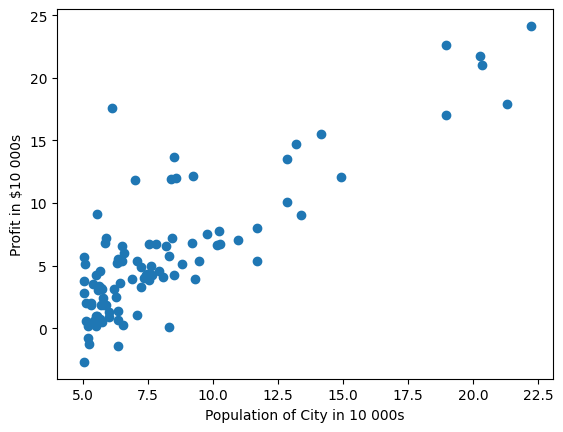

In [44]:
data = np.loadtxt('food_truck_data.csv', delimiter=',')

plt.scatter(data[:, 0], data[:, 1])
plt.xlim(4)
plt.xlabel('Population of City in 10 000s')
plt.ylabel('Profit in $10 000s')
plt.show()

Yes, we (the truck driver) live in a very populous (and also rich) country.

Now, let's try to fit a *linear regression* model to this data. More formally, we are going to search for a hypothesis $h_{\theta} \in H$ which minimizes the cost function $$J(\theta) = \sum_{i=1}^t{err(h_{\theta}(x_i), y_i)}$$
where $t$ is the number of examples, $x_i$ is $i$th example, $y_i$ is $i$th target value, the function $h_{\theta}$ is described as $$h_{\theta}(x) = \theta_0 + \theta_1x$$ and $err(\hat{y}, y)$ is an error function which measures the error that the hypothesis made.

In our example the error function will be **Mean Squared Error** so we will try to find parameters $\theta$ that minimize
$$J(\theta) = \frac{1}{2t}\sum_{i=1}^t(h_{\theta}(x_i) - y_i)^2$$

You may recall from the lectures that one way of doing this is to use an algorithm called **gradient descent**. In each step of gradient descent you will perform a parameter update so that with each step your parameters will come closer to the optimal values.


Putting all of this together, our parameter update now looks as follows:
$$\theta_j = \theta_j - \alpha\frac{1}{t}\sum_{i=1}^{t}(h_{\theta}(x_i) - y_i)x_{i,j}$$
where $t$ is the number of examples, $\alpha$ is learning rate, $x_i$ is $i$th example, $y_i$ is $i$th target value and $x_{i, j}$ is $i$th example's $j$th feature.


<h5 style="color: #1B1BFF">Exercise 1</h5>

In the next cell you can find a small template, already set up with some important variables. We initialize the values of $\theta$ to zero, set our learning rate and number of iterations. Note that we also put target values into a separate variable `y`.

Please finish this setup by preparing the matrix X. It will represent your input matrix where each row is one example. **Remember the intercept term!** (Resulting shape should be (97, 2).)

In [45]:
# set learning rate
alpha = 0.01
# set number of steps of gradient descent
iterations = 1500
# target variables
y = data[:, 1]

# Please, initialize the input matrix X
X = np.column_stack((np.ones(data.shape[0]), data[:, :-1]))
print("Shape of matrix X: {}".format(X.shape))
print("First 5 rows of X: {}".format(X[:5, :]))

Shape of matrix X: (97, 2)
First 5 rows of X: [[1.     6.1101]
 [1.     5.5277]
 [1.     8.5186]
 [1.     7.0032]
 [1.     5.8598]]


In [46]:
grader.check("q1_design_matrix")

q1_design_matrix results: All test cases passed!

<h5 style="color: #1B1BFF">Exercise 2</h5>

Now fill in the body of the function `compute_cost(X, y, theta)` which should compute the cost function described above. Please use vectorized operations rather than loops.

In [47]:
def compute_cost(X, y, theta):
    predictions = X@theta
    residuals = predictions - y
    return np.mean(residuals**2) / 2

In [48]:
grader.check("q2_compute_cost")

q2_compute_cost results: All test cases passed!

<h5 style="color: #1B1BFF">Exercise 3</h5>

Next, we will run our gradient descent algorithm. First, we compute an initial cost. Then in each iteration we update our parameters. A sample loop structure is provided, so you only need to supply the parameter update part.

If implemented correctly, your cost should steadily go down and never increase.

Initial cost: 32.072733877455676
Current cost for iteration 0: 11.544251190088346
Current cost for iteration 100: 5.543906151332324
Current cost for iteration 200: 5.242286812839527
Current cost for iteration 300: 5.031718000727242
Current cost for iteration 400: 4.884597893561807
Current cost for iteration 500: 4.781711605373472
Current cost for iteration 600: 4.709679523517277
Current cost for iteration 700: 4.659182512908471
Current cost for iteration 800: 4.623727375504594
Current cost for iteration 900: 4.598788033851771
Current cost for iteration 1000: 4.581208026914546
Current cost for iteration 1100: 4.568784756385129
Current cost for iteration 1200: 4.559980154561485
Current cost for iteration 1300: 4.5537192954895405
Current cost for iteration 1400: 4.549250188556234


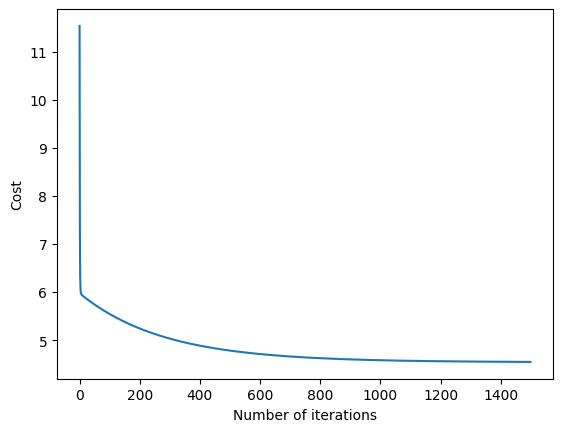

In [49]:
# initialize parameters to zero
theta = np.zeros((X.shape[1],))
# print(theta)

def grad_descent(X, y, theta, alpha, iterations=1500):
    # number of samples
    t = len(y)

    print("Initial cost: {}".format(compute_cost(X, y, theta)))
    history = []

    for i in range(iterations):
        # Update the parameter values on the following line (replace those zeros!)
        for j, x in enumerate(X):
          # print(f"{x = }")
          prediction = x@theta
          residual = prediction - y[j]
          # print(f"{residual = }")
          theta -= (alpha / t) * (residual * x)

        cost = compute_cost(X, y, theta)
        if i % 100 == 0:
            print("Current cost for iteration {}: {}".format(i, cost))
        history.append(cost)

    return theta, history

theta, history = grad_descent(X, y, theta, alpha, iterations)
plt.plot(history)
plt.xlabel('Number of iterations')
plt.ylabel('Cost')
plt.show()

In [50]:
grader.check("q3_grad_descent")

q3_grad_descent results: All test cases passed!

Now we will use your trained parameters to show the linear line they represent with regards to the training data.

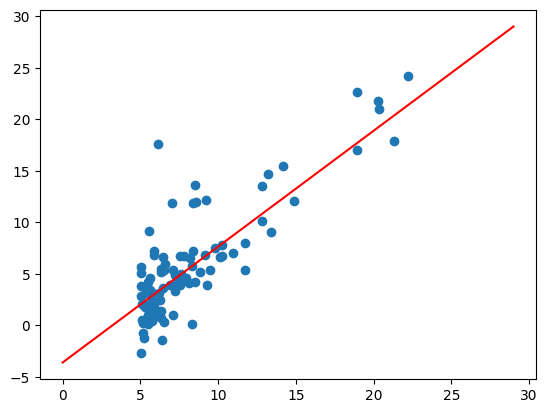

In [51]:
line = np.arange(0, 30)
plt.scatter(data[:, 0], data[:, 1])
plt.plot(np.array([np.ones(30), line]).T.dot(theta), 'r')
plt.show()

<h5 style="color: #1B1BFF">Exercise 4</h5>

Suppose we have two cities, one with 35000 people and second with 70000 people. What would the predicted profits be for each one of them? Store the predicted profits (in $10 000s, the same units as `data`) in `profit_35k` and `profit_70k`.

In [52]:
# COMPUTE HERE
x_35 = np.array([1, 3.5])
x_70 = np.array([1, 7.0])
profit_35k = x_35@theta
profit_70k = x_70@theta

print("Predicted profit for 35000 people: {}".format(profit_35k))
print("Predicted profit for 70000 people: {}".format(profit_70k))

Predicted profit for 35000 people: 0.3444462226953484
Predicted profit for 70000 people: 4.277281454810703


In [53]:
grader.check("q4_food_truck_predictions")

q4_food_truck_predictions results: All test cases passed!

### Part II: Housing

In the variable `data` we loaded a new *housing* data for you. The first column in `data` represents the house size (most probably in square feet), the second column represents the number of bedrooms and the last column is the price of the house. As you can see, the house size is generally 1000 times larger than the number of bedrooms. This is undesirable, as  our model will now have to first learn how to scale the data appropriately. It will most probably cause the training time to be longer or it may even make the model fail to find the underlying relationship (distribution) of the data in question. In other words, the training procedure may cause the cost to diverge.

This can be solved using **feature normalization**, where we make sure that each feature's value has zero mean and unit variance. Usually, this is done by subtracting the *mean* of the features and scaling it down by *standard deviation*. The resulting data will have zero mean and unit variance. (People sometimes say they are "centered" around zero mean while having unit variance.)

Shape of loaded data: (47, 3)


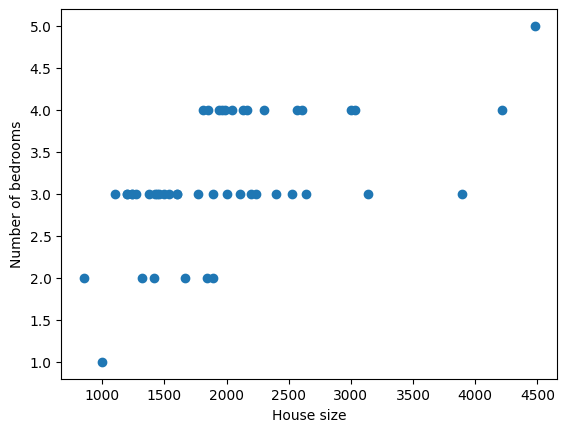

In [54]:
data = np.loadtxt('housing_data.csv', delimiter=',')
print("Shape of loaded data: {}".format(data.shape))
plt.scatter(data[:, 0], data[:, 1])
plt.xlabel('House size')
plt.ylabel('Number of bedrooms')
plt.show()

<h5 style="color: #1B1BFF">Exercise 5</h5>

Load training data (house size, number of bedrooms) into `X` variable and load train target variables into `y`.

Shuffle the rows as well (`np.random.permutation` will do the trick in most cases). For full-batch gradient descent and the normal equation the order of rows makes no difference (the cost is a sum over all examples), but shuffling is a good habit: it matters as soon as you split the data into parts (Exercise 10) or train on mini-batches.

In [55]:
X = data[:, :-1]
y = data[:, -1]
permutation = np.random.permutation(len(X))
X = X[permutation]
y = y[permutation]

In [56]:
grader.check("q5_housing_data")

q5_housing_data results: All test cases passed!

<h5 style="color: #1B1BFF">Exercise 6</h5>

Now, perform feature normalization by taking the *mean* and *standard deviation* of our dataset. Each feature should have its own *mean* and *standard deviation*.

**Note that you need to store these values!**

You want to use your model not only on the training data but also on new, previously unseen data. If you only normalized your training data, your model will see the previously unseen data as a completely different distribution and would have tough time handling it (in other words, it would most probably be close to useless). Long story short, you will need to normalize each new example that you would like to predict on using these values. This *mean* and *standard deviation* are becoming parameters and hence crucial parts of your first *machine learning pipeline*.

**Do not forget to add intercept term!**


#### Do not normalize your target variables! You still want to predict accurate house prices!

Store the mean and standard deviation of each feature in `mean` and `std`, and overwrite `X` with the normalized features (including the intercept column).

In [57]:
# Normalize features HERE
mean = np.mean(X, axis=0)
std = np.std(X, axis=0)
X = np.column_stack((np.ones(len(X)), (X - mean) / std))

print("Training set shape: {}".format(X.shape))

Training set shape: (47, 3)


In [58]:
grader.check("q6_normalization")

q6_normalization results: All test cases passed!

We will now run the same code as before for optimizing parameters.

Your code should already be able to run with arbitrary number of features. If not please rewrite `grad_descent` function with matrix operations so it can handle arbitrary amount of features (and not just one).

Initial cost: 65591548106.45744
Current cost for iteration 0: 29984407609.46772
Current cost for iteration 100: 2044789659.4526203
Current cost for iteration 200: 2044789659.4094741
Current cost for iteration 300: 2044789659.4094741
Current cost for iteration 400: 2044789659.4094741
Current cost for iteration 500: 2044789659.4094741
Current cost for iteration 600: 2044789659.4094741
Current cost for iteration 700: 2044789659.4094741
Current cost for iteration 800: 2044789659.4094741
Current cost for iteration 900: 2044789659.4094741
Current cost for iteration 1000: 2044789659.4094741
Current cost for iteration 1100: 2044789659.4094741
Current cost for iteration 1200: 2044789659.4094741
Current cost for iteration 1300: 2044789659.4094741
Current cost for iteration 1400: 2044789659.4094741


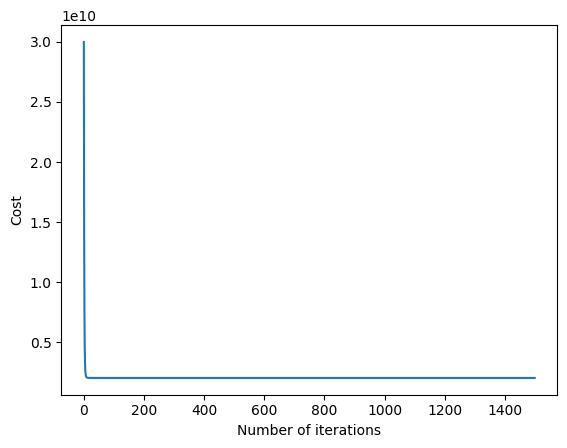

In [59]:
# initialize parameters to zero
theta = np.zeros((X.shape[1],))
alpha = 0.4

theta, history = grad_descent(X, y, theta, alpha)
plt.plot(history)
plt.xlabel('Number of iterations')
plt.ylabel('Cost')
plt.show()

<h5 style="color: #1B1BFF">Exercise 7</h5>

Next, please compute the value for house with size of 1650 square feet and 3 bedrooms (it should be around 290000). Store the normalized example (including the intercept term) in `house` and the predicted price in `price`.

In [60]:
# COMPUTE HERE

house = np.array([1650, 3])
house = (house - mean) / std
house = np.insert(house, 0, 1)
price = house@theta
print("House price computed by running gradient descent: {}".format(price))

House price computed by running gradient descent: 291728.43679655896


In [61]:
grader.check("q7_house_price_gd")

q7_house_price_gd results: All test cases passed!

----------------------------------------------------------------------------------------

<h5 style="color: #1B1BFF">Exercise 8</h5>

In the lecture you also learned that the closed-form solution to linear regression can be described as follows:

$$\theta = (X^{T}X)^{-1}X^{T}y$$

This form finds exact solution without any iterations, which is pretty nice. (There are some caveats -- for instance, $X^{T}X$ has to be invertible -- but let us not talk about those now.)

Please provide body of the function `compute_theta_norm_eq` which will return parameters $\theta$ based on given data in the next cell. Rather than computing the inverse explicitly with `np.linalg.inv`, solve the linear system $X^{T}X\theta = X^{T}y$ with `np.linalg.solve` -- it gives the same result, but is faster and numerically more stable.


Use this function to check if the price of house with 1650 size and 3 bedrooms matches the one found by gradient descent. Store the price in `price`.

In [62]:
def compute_theta_norm_eq(X, y):
    return np.linalg.solve(X.T@X, X.T@y)

In [63]:
theta = compute_theta_norm_eq(X, y)

price = house@theta
print("House price computed by normal equations: {}".format(price))

House price computed by normal equations: 293081.4643348961


In [64]:
grader.check("q8_normal_equation")

q8_normal_equation results: All test cases passed!

<!-- BEGIN QUESTION -->

<h5 style="color: #1B1BFF">Exercise 9</h5>

If we print raw values of $\theta$ what can we conclude about our features? Please, provide brief explanations.

Write your answer into the `q9_answer` string two cells below.

In [65]:
print(theta)

[340412.65957447 109447.79646964  -6578.35485416]


In [66]:
# Write your answer as plain text between the triple quotes.
q9_answer = """
theta_0 is an average price, that is around 340k,
theta_1 is an impact of the flat size - for 1 square foot rises the price for about 11k,
theta_2 says that for 1 room, the price of a flat decreases for about 6.6k
"""

<!-- END QUESTION -->

### Part III: Concrete

Again, in `data` variable we have loaded a new dataset for you. This time it is related to compressive strength of concrete.

Concrete is the most important material in civil engineering and the concrete compressive strength is a highly nonlinear function of age and ingredients. This data consists out of 8 features:

* `(component 1)` Cement  - kg in a m3 mixture
* `(component 2)` Blast Furnace Slag  - kg in a m3 mixture
* `(component 3)` Fly Ash  - kg in a m3 mixture
* `(component 4)` Water  - kg in a m3 mixture
* `(component 5)` Superplasticizer  - kg in a m3 mixture
* `(component 6)` Coarse Aggregate  - kg in a m3 mixture
* `(component 7)` Fine Aggregate  - kg in a m3 mixture
* `(component 8)` Age - Day (1~365)

and its target variable:

* `(component 9)` *Concrete compressive strength - MPa*


In [67]:
data = np.loadtxt('concrete_data.csv', delimiter=',')
print("Shape of concrete compressive strength data: {}".format(data.shape))

Shape of concrete compressive strength data: (1030, 9)


If there is something we want our model to do, we want it to generalize. To "learn" the underlying data distribution from the data it saw, so that we could apply it on data it did not see in training. But how do we know how well does our model generalize?

For this we usually split any dataset we have into three chunks. One is called **train set** and it is used to train the model. The second one, usually taken from the training set is called **validation set** and it is used to optimize hyperparameters of our model (such as learning rate, form of regularization, strength of regularization, etc...). The last chunk of data is called **test set** and it is used **only once**! It is sometimes called also *hold-out* set because we take the data at the beginning and store it somewhere and use it only in the end to see how well our model can *generalize* on previously unseen data.


<h5 style="color: #1B1BFF">Exercise 10</h5>

Please split the concrete data (in the `data` variable) into these three sets. Use the provided variables to store the appropriate sets. Split the data in 60:20:20 ratio (60% for training, 20% for validation set, 20% for test set). Resulting shape should be `(618, 8)`, `(206, 8)` and `(206, 8)`, respectively.

**Shuffle the data first.** The concrete data file is ordered: without shuffling, the mean compressive strength is about 39.6 MPa in the first 60% of the rows but only 27.5 MPa in the next 20%, so the three sets would not come from the same distribution.

We normalize the data (and add the intercept term) for you this time.

In [68]:
# Shuffle the data
permutation = np.random.permutation(len(data))
data = data[permutation]
X, y = data[:, :-1], data[:, -1]

n = len(X)
train_size, val_size, test_size = int(n*0.6), int(n*0.2), int(n*0.2)
# print(f"Sizes: {train_size}, {val_size}, {test_size}")

split_point1 = train_size
split_point2 = train_size + val_size

X_train = X[:split_point1, :]
y_train = y[:split_point1]

X_val = X[split_point1:split_point2, :]
y_val = y[split_point1:split_point2]

X_test = X[split_point2:, :]
y_test = y[split_point2:]

print("Train set X: {} y: {}".format(X_train.shape, y_train.shape))
print("Validation set X: {} y: {}".format(X_val.shape, y_val.shape))
print("Test set X: {} y: {}".format(X_test.shape, y_test.shape))

Train set X: (618, 8) y: (618,)
Validation set X: (206, 8) y: (206,)
Test set X: (206, 8) y: (206,)


In [69]:
grader.check("q10_split")

q10_split results: All test cases passed!

In [70]:
# normalize the data based on training mean and standard deviation
# (taking the last 8 columns keeps this cell safe to re-run: it skips the intercept added below)
X_train, X_val, X_test = X_train[:, -8:], X_val[:, -8:], X_test[:, -8:]
mean = np.mean(X_train, axis=0)
std = np.std(X_train, axis=0)

# add the intercept term as the first column
add_intercept = lambda A: np.c_[np.ones(len(A)), A]
X_train = add_intercept((X_train - mean) / std)
X_val = add_intercept((X_val - mean) / std)
X_test = add_intercept((X_test - mean) / std)

Now we will use the previously constructed function `compute_theta_norm_eq` to compute new parameters for this dataset.

In [71]:
theta = compute_theta_norm_eq(X_train, y_train)
print("Train MSE error: {}".format(compute_cost(X_train, y_train, theta)))
print("Validation MSE error: {}".format(compute_cost(X_val, y_val, theta)))

Train MSE error: 55.153360823923364
Validation MSE error: 51.93075794970198


Both errors are high and close to each other: the relationship between the ingredients and the strength is nonlinear, and a simple linear function cannot capture it. This phenomenon is called **underfitting**. You can sometimes run into the opposite phenomenon called **overfitting**, where the training error is low but the validation error is high. It often occurs when we have a model that is too complex/powerful for our task (i.e. a lot of free parameters for optimization and not too much data to train and test on).

However, you may recall from the lectures that linear regression can be generalized to fit more complex functions. We can transform simple linear regression into a more complex model by adding various features to the input vector. For instance, if we would like to have data of more quadratic nature, we can just make new features by squaring  it (that is squaring the input vector).

On the other hand, if we "*over-do this*", the model gets enough freedom to fit the noise in the training samples rather than the underlying function.

Suppose we had data of quadratic nature, and a model that used features all the way up to the power of 9. The quadratic function we are after is in this space of degree-9 polynomials (all the higher coefficients would be 0), but least squares does not look for it: it picks the degree-9 polynomial that gets closest to the *noisy* training points. That polynomial typically wiggles through the samples and behaves very differently from the true function between and beyond them -- the model overfits.

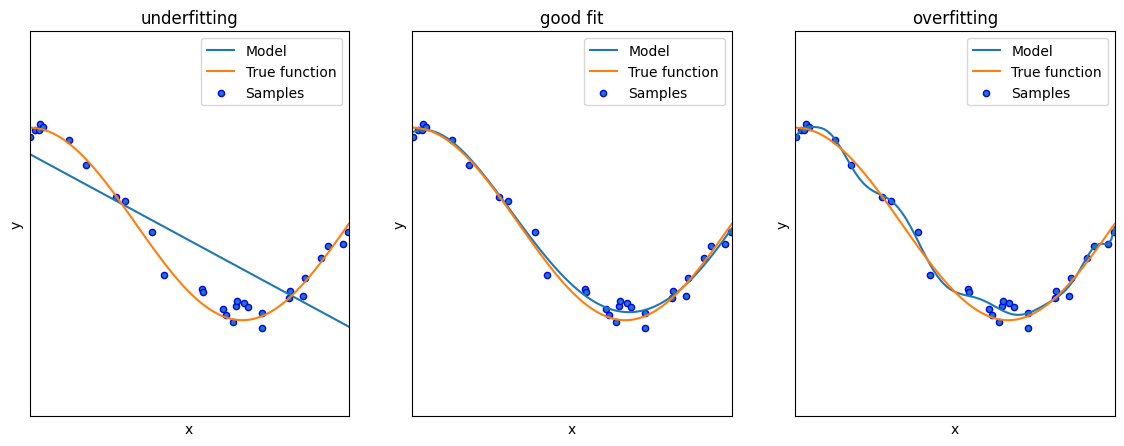

In [72]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

def true_fun(X):
    return np.cos(1.5 * np.pi * X)

n_samples = 30
degrees = [1, 4, 15]

rng = np.random.default_rng(0)
X_demo = np.sort(rng.random(n_samples))
y_demo = true_fun(X_demo) + rng.normal(size=n_samples) * 0.1
titles = ['underfitting', 'good fit', 'overfitting']

plt.figure(figsize=(14, 5))
for i in range(len(degrees)):
    ax = plt.subplot(1, len(degrees), i + 1)
    plt.setp(ax, xticks=(), yticks=())

    polynomial_features = PolynomialFeatures(degree=degrees[i],
                                             include_bias=False)
    linear_regression = LinearRegression()
    pipeline = Pipeline([("polynomial_features", polynomial_features),
                         ("linear_regression", linear_regression)])
    pipeline.fit(X_demo[:, np.newaxis], y_demo)

    x_plot = np.linspace(0, 1, 100)
    plt.plot(x_plot, pipeline.predict(x_plot[:, np.newaxis]),
             label="Model")
    plt.plot(x_plot, true_fun(x_plot), label="True function")
    plt.scatter(X_demo, y_demo, edgecolor='b', s=20, label="Samples")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.xlim((0, 1))
    plt.ylim((-2, 2))
    plt.legend(loc="best")
    plt.title(titles[i])
plt.show()

<h5 style="color: #1B1BFF">Exercise 11</h5>

Your task now is to find good fitting features. Build new features (e.g. polynomial ones) from the original columns of `X_train` (that is `X_train[:, 1:]`, without the intercept) and keep exactly one intercept column, so that the training error would be low and validation error would be also low. (If you use scikit-learn's `PolynomialFeatures`, note that it adds the column of ones for you.)

Apply the same feature transformation to `X_val` and `X_test`, so that your `theta` can be evaluated on them. We check that the training error is low (MSE below 40) and that the validation error does not blow up (MSE below 60).


In [73]:
# COMPUTE HERE
degree = 2
polynomial_features = PolynomialFeatures(degree=degree, include_bias=True)
X_train = polynomial_features.fit_transform(X_train[:, 1:])
X_val = polynomial_features.fit_transform(X_val[:, 1:])

theta = compute_theta_norm_eq(X_train, y_train)

print("Train MSE error: {}".format(compute_cost(X_train, y_train, theta)))
print("Validation MSE error: {}".format(compute_cost(X_val, y_val, theta)))

Train MSE error: 26.103656464465473
Validation MSE error: 29.836317197606036


In [74]:
X_test = polynomial_features.fit_transform(X_test[:, 1:])

In [75]:
grader.check("q11_polynomial_features")

q11_polynomial_features results: All test cases passed!

<!-- BEGIN QUESTION -->

<h5 style="color: #1B1BFF">Exercise 12</h5>

Please also provide a brief explanation of your setup and approach, and describe in detail when (i.e. at what polynomial degree) you stopped experiencing *underfitting* and when you found you were experiencing *overfitting*.

Write your answer into the `q12_answer` string below.

In [76]:
# Write your answer as plain text between the triple quotes.
q12_answer = """
The first choice of 2 was enough (with addition of the intercept term.)
"""

<!-- END QUESTION -->

Run your model on the test set only once, when you are **sure** that you found a good fit (low training error, low validation error).

In [77]:
print("Your final test error: {}".format(compute_cost(X_test, y_test, theta)))

Your final test error: 27.34667289024423


### Final question (Exercise 13)


One big disadvantage of normal equations is that solving the $n \times n$ system $X^{T}X\theta = X^{T}y$ gets very expensive as the number of features $n$ grows (roughly $n^3$ operations, plus $n^2$ memory for $X^{T}X$). Gradient descent only needs matrix-vector products, which is why it is used for large models.

In the variables `X` and `y` we loaded some sample data (the first column of `X` is the intercept term). Please run your implementation of gradient descent algorithm on it.

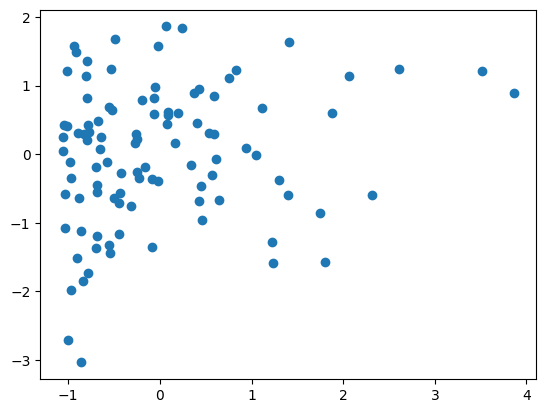

Initial cost: 0.15973736167834873
Current cost for iteration 0: 0.09325099240462825
Current cost for iteration 100: 0.038578279098190386
Current cost for iteration 200: 0.038578279098190386
Current cost for iteration 300: 0.038578279098190386
Current cost for iteration 400: 0.038578279098190386
Current cost for iteration 500: 0.038578279098190386
Current cost for iteration 600: 0.038578279098190386
Current cost for iteration 700: 0.038578279098190386
Current cost for iteration 800: 0.038578279098190386
Current cost for iteration 900: 0.038578279098190386
Current cost for iteration 1000: 0.038578279098190386
Current cost for iteration 1100: 0.038578279098190386
Current cost for iteration 1200: 0.038578279098190386
Current cost for iteration 1300: 0.038578279098190386
Current cost for iteration 1400: 0.038578279098190386


In [82]:
data = np.loadtxt('bonus_data.csv', delimiter=',')
X = data[:3, :].T
y = data[3, :]

X = X[:, 1:]
X = (X - np.mean(X, axis=0)) / np.std(X, axis=0)
X = np.column_stack((np.ones(len(X)), X))


plt.scatter(X[:, 1], X[:, 2])
plt.show()

theta = np.zeros((3,))
alpha = 0.4

theta, history = grad_descent(X, y, theta, alpha)

In [83]:
print("Your theta coefficients: {}".format(theta))

Your theta coefficients: [0.48350081 0.04454761 0.02085869]


To compare the results, please also run the "out-of-the-box" implementation of linear regression from `sklearn` library.

In [84]:
from sklearn.linear_model import LinearRegression

linear_regression = LinearRegression()
# scikit-learn fits the intercept itself, so we leave out our column of ones
linear_regression.fit(X[:, 1:], y)

print("scikit-learn's theta coefficients: {}".format(np.r_[linear_regression.intercept_, linear_regression.coef_]))

scikit-learn's theta coefficients: [0.48957627 0.0437703  0.02043424]


<!-- BEGIN QUESTION -->

<h5 style="color: #1B1BFF">Exercise 13</h5>

Please, describe what happened.

*Hint:* contrast your gradient descent with the out-of-the-box implementation from `sklearn` above. Why does one of them find sensible coefficients while the other does not?

How is this phenomenon called?
How can it be resolved?
What take-home message do we take from this whole "bonus" experience?

Write your answer into the `q13_answer` string below. Please make it brief: at most three sentences.

In [81]:
# Write your answer as plain text between the triple quotes.
q13_answer = """
Write your answer here (replace this text).
"""

<!-- END QUESTION -->

*If you need any help with this assignment, please feel free to contact the course TAs, whose contact info can be found on the [course website](http://compbio.fmph.uniba.sk/vyuka/ml/).*


**Thanks for reading this far!**